In [ ]:
# Comparison script

#-------------------------------------------- TO DO ----------------------------------------------------#
# 1. When z0 RANS simulations are done, implement and run full script                                   #
# 2. implement +/- sign on rightside plot in varying_two_parameters(), maybe change it to x,y error     #
# 3. add club comparison functionality                                                                  #
# 4. Clean up titles and legends on plots, final sizing corrections                                     #
# 5. Clean up script                                                                                    #
# 6. Create overview as a content list in the beginning of the script                                   #
#-------------------------------------------------------------------------------------------------------#

In [4]:
# 1.1 --- Importing packages ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Tracer import WindField, Trajectory
from Tracer.solvers import solver_rk45, solver_euler

In [19]:
# play field parameters - these make up the baseline shot
P0=np.array([0, 0, 0])
nx = 500        # length of play field
ny = 200        # width of play field
nz = 100        # height of play field
dt = 0.01       # time step

# Basis shot parameters - if not otherwise specified, these are used
shot_speed = 76.44384   # intital velocity
shot_angle = 10.4       # initial angle for trajectory	
shot_spin = 2545        # initial spin
spin_axis = 0           # spin axis adding impurity to the spin
orientation = 0         # play direction

# Basis wind parameters - if not otherwise specified, these are used
U_ref = 6      # reference wind speed at 10 meters above ground (6 m/s is approx. danish average)
z0 = 0.03       # surface roughness
direction = 0   # wind direction (0 is tailwind, 180 is headwind)

# script parameters
design_n = 10           # design parameter for # of values in design library
r = 150                 # Approximate radius of playfield, used for rotation and movement of player position

In [ ]:
# filepaths for RANS simulations with varying z0
datafile01 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z005m_2m_cartesian.nc'
datafile02 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z005m_2m_cartesian.nc'
datafile03 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z005m_2m_cartesian.nc'
datafile04 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z005m_2m_cartesian.nc'
datafile05 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z005m_2m_cartesian.nc'
datafile06 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z005m_2m_cartesian.nc'
datafile07 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z005m_2m_cartesian.nc'
datafile08 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z005m_2m_cartesian.nc'
datafile09 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z005m_2m_cartesian.nc'
datafile10 = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_z005m_2m_cartesian.nc'

z0_file_library = {
    0.001:              datafile01,
    0.00215443469:      datafile02,
    0.00464158883:      datafile03,
    0.01:               datafile04,
    0.0215443469:       datafile05,
    0.03:               datafile06, # baseline
    0.0464158883:       datafile07,
    0.1:                datafile08,
    0.215443469:        datafile09,
    1.0:                datafile10
}

basefile = datafile06

def get_rans_file(z0_value):
    keys = np.array(list(z0_file_library.keys()))
    nearest = keys[np.argmin(np.abs(keys - z0_value))]
    return z0_file_library[nearest]

# baseline values
baseline_values = {
    "shot_speed": shot_speed,
    "shot_angle": shot_angle,
    "shot_spin": shot_spin,
    "U_ref": U_ref,
    "z0": z0,
    "direction": direction,
    "file":basefile,
}

def include_baseline(values, baseline):
    """
    Ensures baseline is included while keeping exactly n_total samples.
    Replaces the nearest sampled value if baseline is not already present.
    """
    values = np.array(values)
    # if baseline already exists, just return sorted values
    if np.isclose(values, baseline).any():
        return np.sort(values)
    # find nearest existing point and replace it
    idx = np.argmin(np.abs(values - baseline))
    values[idx] = baseline
    return np.sort(values)

# parameter library
parameter_library = {
    "shot_speed": {
        "values": include_baseline(np.linspace(35, 85, design_n), shot_speed),
        "name": "Shot speed",
        "unit": "m/s"
    },
    "shot_angle": {
        "values": include_baseline(np.linspace(5, 25, design_n), shot_angle),
        "name": "Shot angle",
        "unit": "deg"
    },
    "shot_spin": {
        "values": include_baseline(np.linspace(2000, 10000, design_n), shot_spin),
        "name": "Shot spin",
        "unit": "rpm"
    },
    "U_ref": {
        "values": include_baseline(np.linspace(2, 10, design_n), U_ref),
        "name": "Wind speed",
        "unit": "m/s"
    },
    "z0": {
        "values": include_baseline(np.logspace(np.log10(0.001), np.log10(1), design_n), z0),
        "name": "Roughness",
        "unit": "m"
    },
    "direction": {
        "values": include_baseline(np.linspace(0, 180, design_n), direction),
        "name": "Wind direction",
        "unit": "deg"
    }
}

# --- player positions ----
new_P0 = np.array([0, 0, 0])    # blank position array
rotation_configs = []
for ang in parameter_library['direction']['values']:
    theta = ang * (np.pi/180.0)
    x = -np.cos(theta) * r
    y = -np.sin(theta) * r
    rotation_configs.append({"direction": ang,"orientation": ang,"P0": np.array([x, y, 0])})

# --- plot nice
def get_rotated_geometry(direction, r=r):
    theta = direction * (np.pi/180.0)

    x = -np.cos(theta) * r
    y = -np.sin(theta) * r
    P0_new = np.array([x, y, 0])

    orientation_new = direction   # may become direction+180 depending on convention

    return P0_new, orientation_new

def transform_to_local_frame(p, direction):
    P0_used, _ = get_rotated_geometry(direction)

    theta = direction * (np.pi/180.0)

    # translate
    xt = p[:, 0] - P0_used[0]
    yt = p[:, 1] - P0_used[1]

    # rotate into shot-aligned frame
    x_local = xt * np.cos(theta) + yt * np.sin(theta)
    y_local = -xt * np.sin(theta) + yt * np.cos(theta)

    z_local = p[:, 2]

    return np.column_stack((x_local, y_local, z_local))

def is_baseline(param_key, value, tol=1e-8):
    return np.isclose(value, baseline_values[param_key], atol=tol)

def format_param(v):
    if v == 0:
        return "0"
    elif abs(v) < 1e-2:
        return f"{v:.2e}"
    elif abs(v) >= 1000:
        return f"{v:.0f}"
    elif abs(v) >= 1:
        return f"{v:.2f}".rstrip('0').rstrip('.')
    else:
        return f"{v:.4f}".rstrip('0').rstrip('.')

# --- Error Models ---
def percent_distance_error(ref_p, test_p):
    dx = test_p[-1, 0] - ref_p[-1, 0]
    dy = test_p[-1, 1] - ref_p[-1, 1]
    norm = np.sqrt((ref_p[-1, 0]-ref_p[0, 0])**2 + (ref_p[-1, 1]-ref_p[0, 1])**2)
    return np.sqrt(dx**2 + dy**2) / norm * 100

def distance_error(ref_p, test_p):
    dx = test_p[-1, 0] - ref_p[-1, 0]
    dy = test_p[-1, 1] - ref_p[-1, 1]
    return np.sqrt(dx**2 + dy**2)

def x_distance_error(ref_p, test_p):
    return test_p[-1, 0] - ref_p[-1, 0]

def y_distance_error(ref_p, test_p):
    return test_p[-1, 1] - ref_p[-1, 1]

def build_wind(profile, U_ref, z0, direction, rans_file=None):
    if profile == 'uniform':
        return WindField(profile='uniform', U_ref=U_ref, direction=direction)

    elif profile == 'log':
        return WindField(profile='log', U_ref=U_ref, z0=z0, direction=direction)

    elif profile == 'rans':
        return WindField(profile='rans', ds=rans_file, U_ref=U_ref)

    else:
        raise ValueError(f"Unknown profile: {profile}")
    
    
def solve_profile(profile, shot_speed, shot_angle, shot_spin,
                  U_ref, z0, direction, orientation_used, P0_used, rans_file):

    wind = build_wind(profile, U_ref, z0, direction, rans_file)

    traj = Trajectory(
        ball_speed=shot_speed,
        launch_angle=shot_angle,
        spin_rate=shot_spin,
        spin_axis=spin_axis,
        wind=wind,
        orientation=orientation_used,
        P0=P0_used
    )

    traj.solve(solver='euler', dt=dt)
    return traj.p

def run_simulation(shot_speed=shot_speed, shot_angle=shot_angle,
                   shot_spin=shot_spin, U_ref=U_ref,
                   z0=z0, direction=direction,
                   test='uniform', ref='rans'):

    # coupled geometry from direction
    P0_used, orientation_used = get_rotated_geometry(direction)

    # coupled RANS dataset from z0
    rans_file = get_rans_file(z0)

    # only solve the two requested profiles
    ref_p = solve_profile(ref, shot_speed, shot_angle, shot_spin,
                          U_ref, z0, direction,
                          orientation_used, P0_used, rans_file)

    test_p = solve_profile(test, shot_speed, shot_angle, shot_spin,
                           U_ref, z0, direction,
                           orientation_used, P0_used, rans_file)

    return ref_p, test_p

def varying_parameter(param_key, shot_speed=shot_speed, shot_angle=shot_angle,
                      shot_spin=shot_spin, U_ref=U_ref,
                      z0=z0, direction=direction,
                      test='uniform', ref='rans'):

    p = parameter_library[param_key]
    param = p["values"]

    param_results = []
    param_errors = []
    param_abs_errors = []
    param_x_errors = []
    param_y_errors = []

    for value in param:

        kwargs = {
            "shot_speed": shot_speed,
            "shot_angle": shot_angle,
            "shot_spin": shot_spin,
            "U_ref": U_ref,
            "z0": z0,
            "direction": direction
        }

        kwargs[param_key] = value

        ref_p, test_p = run_simulation(**kwargs, test=test, ref=ref)

        param_results.append((ref_p, test_p))
        param_errors.append(percent_distance_error(ref_p, test_p))
        param_abs_errors.append(distance_error(ref_p, test_p))
        param_x_errors.append(x_distance_error(ref_p, test_p))
        param_y_errors.append(y_distance_error(ref_p, test_p))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [6, 4]})
    ax1, ax2 = axes
    colors = plt.cm.viridis(np.linspace(0, 1, len(param_results)))

    # --- 1. Trajectories ---
    for i, (ref_p, test_p) in enumerate(param_results):

        ref_plot = transform_to_local_frame(ref_p, param[i] if param_key=="direction" else direction)
        test_plot = transform_to_local_frame(test_p, param[i] if param_key=="direction" else direction)

        if is_baseline(param_key, param[i]):

            ax1.plot(ref_plot[:, 0], ref_plot[:, 2],
                     color='black', linewidth=3,
                     label=f"B {ref.capitalize()}, {format_param(param[i])} {p['unit']}")

            ax1.plot(test_plot[:, 0], test_plot[:, 2], '--',
                     color='black', linewidth=3,
                     label=f"B {test.capitalize()}, {format_param(param[i])} {p['unit']}")
        else:
            ax1.plot(ref_plot[:, 0], ref_plot[:, 2],
                     color=colors[i],
                     label=f"{ref.capitalize()}, {format_param(param[i])} {p['unit']}")

            ax1.plot(test_plot[:, 0], test_plot[:, 2], '--',
                     color=colors[i],
                     label=f"{test.capitalize()}, {format_param(param[i])} {p['unit']}")

    ax1.set_xlabel("Length (m)")
    ax1.set_ylabel("Height (m)")
    ax1.set_title(f"Trajectories with varying {p['name']}")
    ax1.legend(loc='center right', bbox_to_anchor=(-0.15, 0.5), fontsize=8)

    # --- 2. X vs Y Error ---
    for i in range(len(param)):
        if is_baseline(param_key, param[i]):
            ax2.scatter(param_y_errors[i], param_x_errors[i],
                        color='black', marker='x', s=120, linewidths=3,
                        label='Baseline')
        else:
            ax2.scatter(param_y_errors[i], param_x_errors[i],
                        color=colors[i],
                        label=f"{format_param(param[i])} {p['unit']}")

        ax2.text(param_y_errors[i], param_x_errors[i],
                 format_param(param[i]), fontsize=8)

    ax2.axhline(0, linestyle='--')
    ax2.axvline(0, linestyle='--')
    ax2.set_xlabel("Y error (m)")
    ax2.set_ylabel("X error (m)")
    ax2.set_title("Directional Error (Y vs X)")
    ax2.grid()

    plt.tight_layout()
    plt.show()

def varying_two_parameters(param1_key, param2_key,
                           shot_speed=shot_speed, shot_angle=shot_angle,
                           shot_spin=shot_spin, U_ref=U_ref,
                           z0=z0, direction=direction,
                           test='uniform', ref='rans'):

    p1 = parameter_library[param1_key]
    p2 = parameter_library[param2_key]

    param1 = p1["values"]
    param2 = p2["values"]

    error_grid_percent = []
    error_grid = []

    for val1 in param1:
        row_errors_percent = []
        row_errors = []

        for val2 in param2:

            kwargs = {
                "shot_speed": shot_speed,
                "shot_angle": shot_angle,
                "shot_spin": shot_spin,
                "U_ref": U_ref,
                "z0": z0,
                "direction": direction
            }

            kwargs[param1_key] = val1
            kwargs[param2_key] = val2

            ref_p, test_p = run_simulation(**kwargs, test=test, ref=ref)

            row_errors_percent.append(percent_distance_error(ref_p, test_p))
            row_errors.append(distance_error(ref_p, test_p))

        error_grid_percent.append(row_errors_percent)
        error_grid.append(row_errors)

    error_grid_percent = np.array(error_grid_percent)
    error_grid = np.array(error_grid)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # --- Heatmap ---
    im = ax1.imshow(error_grid_percent, origin='lower', aspect='auto')

    base1 = baseline_values[param1_key]
    base2 = baseline_values[param2_key]

    i_base = np.where(np.isclose(param1, base1))[0][0]
    j_base = np.where(np.isclose(param2, base2))[0][0]

    ax1.scatter(j_base, i_base,
                color='black', marker='x', s=200, linewidths=3,
                label='Baseline')

    cbar = plt.colorbar(im, ax=ax1)
    cbar.set_label(f"{test.capitalize()} deviation from {ref.capitalize()} (%)")

    ax1.set_xticks(range(len(param2)))
    ax1.set_yticks(range(len(param1)))
    ax1.set_xticklabels([format_param(v) for v in param2], rotation=30)
    ax1.set_yticklabels([format_param(v) for v in param1])

    ax1.set_xlabel(f"{p2['name']} ({p2['unit']})")
    ax1.set_ylabel(f"{p1['name']} ({p1['unit']})")
    ax1.set_title(f"{p1['name']} vs {p2['name']}")

    # --- Line plot ---
    colors = plt.cm.viridis(np.linspace(0, 1, len(param1)))

    for i, val1 in enumerate(param1):
        ax2.plot(param2, error_grid[i, :],
                 marker='o',
                 color=colors[i],
                 label=f"{p1['name']}={format_param(val1)} {p1['unit']}")

    ax2.scatter(param2[j_base], error_grid[i_base, j_base],
                color='black',
                marker='x',
                s=150,
                linewidths=3,
                zorder=5,
                label='Baseline')

    ax2.set_xlabel(f"{p2['name']} ({p2['unit']})")
    ax2.set_ylabel("Landing position deviation (m)")
    ax2.set_title(f"{test.capitalize()} relative to {ref.capitalize()}")
    ax2.set_xticks(param2)
    ax2.set_xticklabels([format_param(v) for v in param2], rotation=30)
    ax2.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
    ax2.grid()

    plt.tight_layout()
    plt.show()

Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0


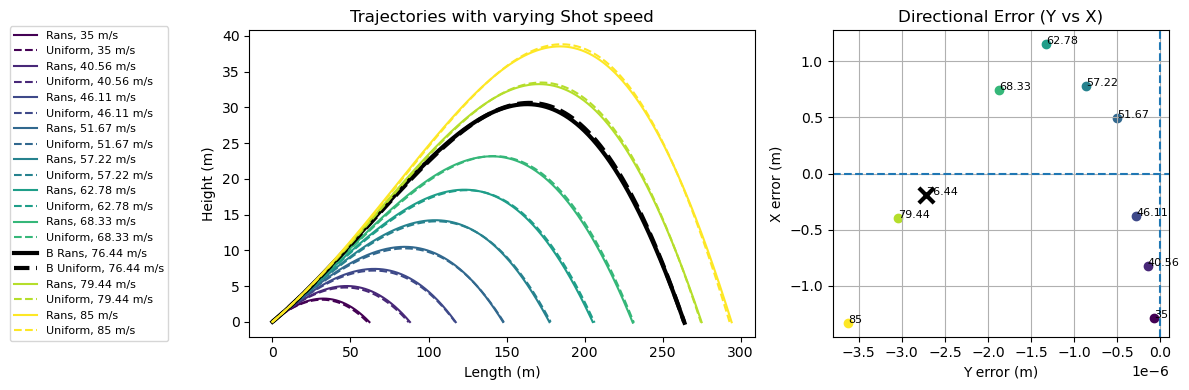

Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0


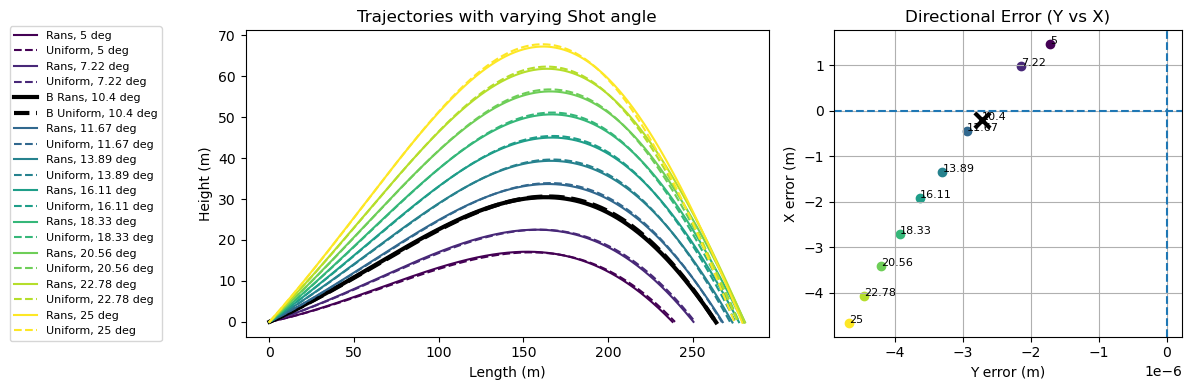

Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0


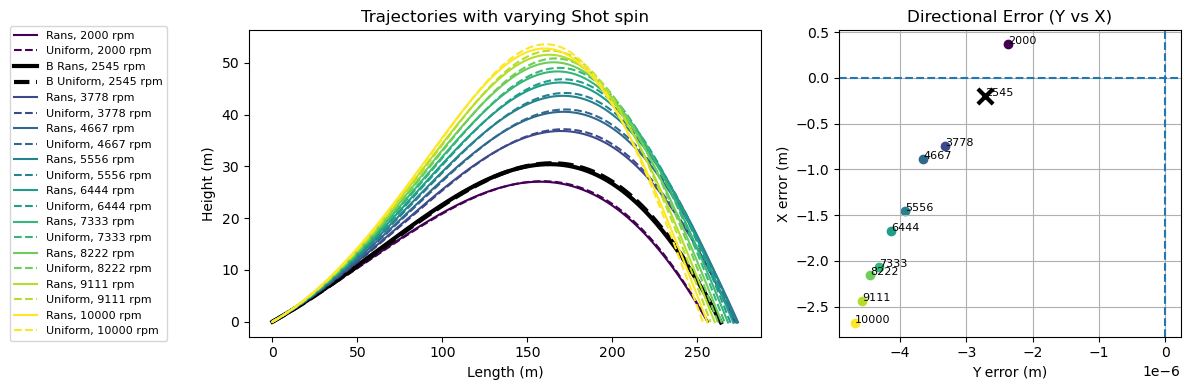

In [ ]:
# Varying shot parameters
varying_parameter("shot_speed", test='uniform', ref='rans')
varying_parameter("shot_angle", test='uniform', ref='rans')
varying_parameter("shot_spin", test='uniform', ref='rans')

Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=2.0, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=2.888888888888889, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=3.7777777777777777, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=4.666666666666666, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6.0, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6.444444444444445, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=7.333333333333333, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=8.222222222222221, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=9.11111111111111, z0=0.03, z_ref=10.0
Sy

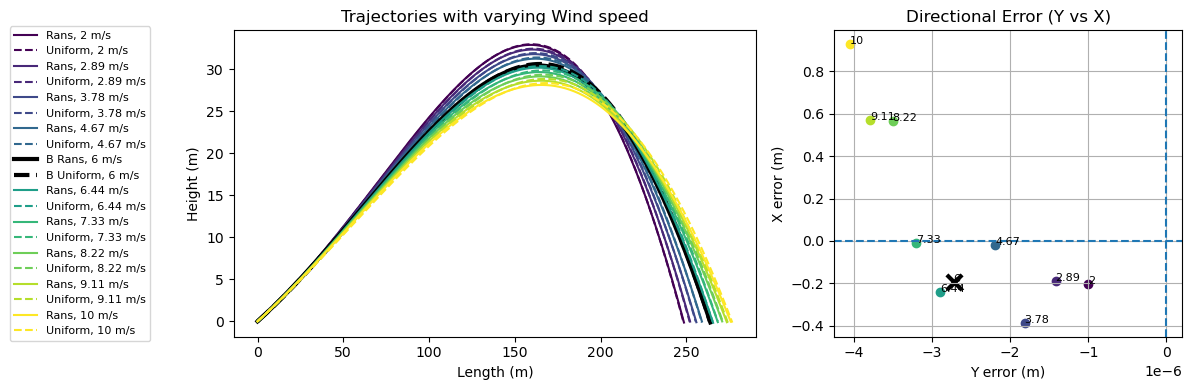

Synthesizing wind field with parameters:  z_height=100, direction=0.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=20.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=40.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=60.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=80.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=100.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=120.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=140.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=160.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=180.0, U_ref=6, z0=0.0

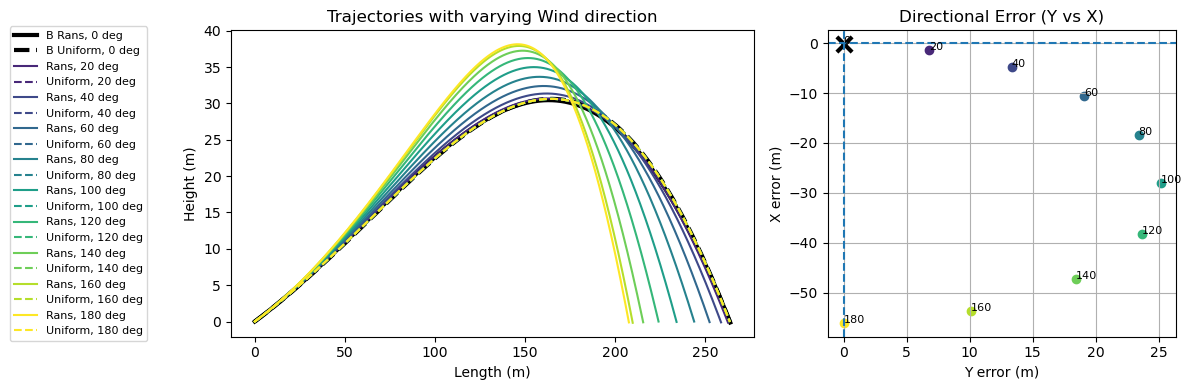

In [ ]:
# Varying env parameters
varying_parameter("U_ref", test='uniform', ref='rans')
#varying_parameter("z0", test='uniform', ref='rans')
varying_parameter("direction", test='uniform', ref='rans')

Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind fi

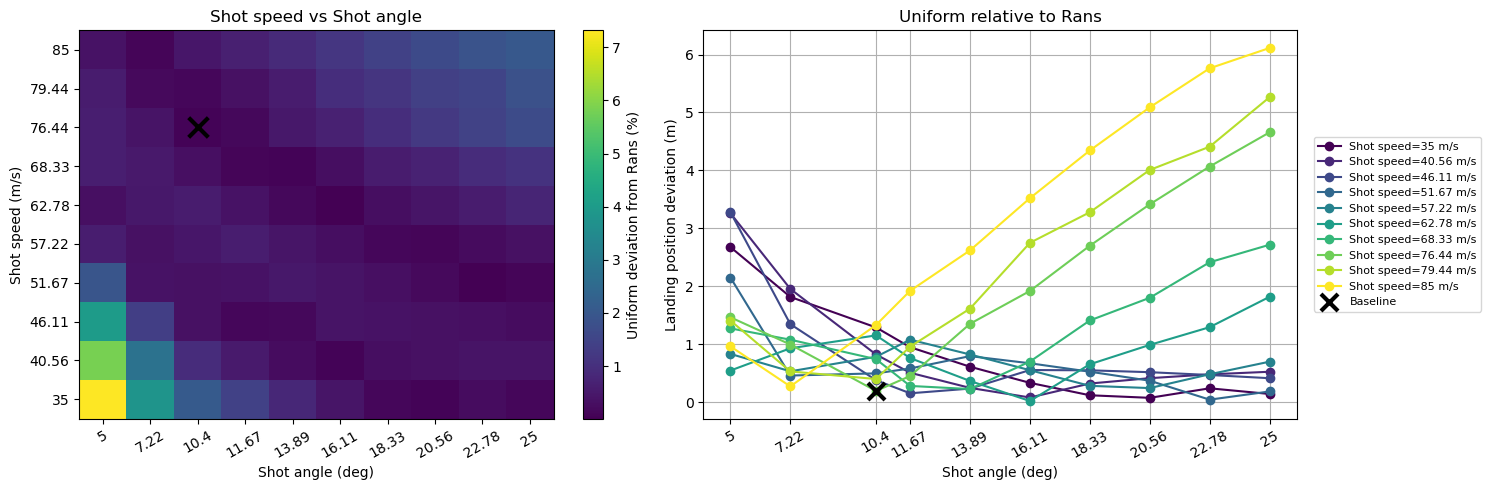

Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind fi

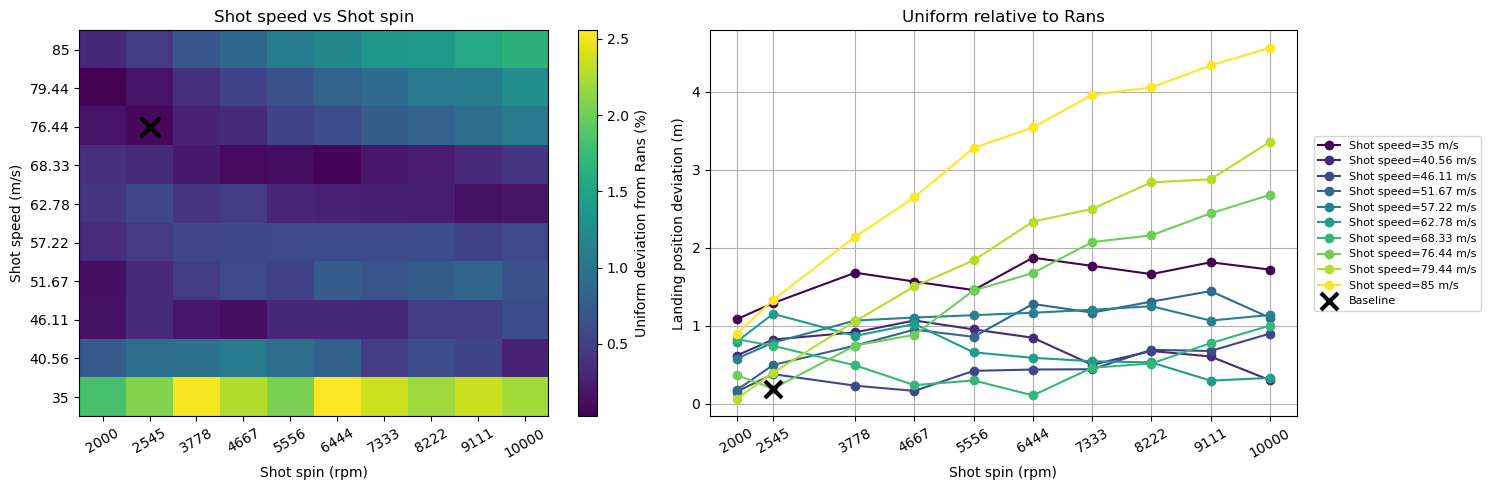

Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=2.0, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=2.888888888888889, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=3.7777777777777777, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=4.666666666666666, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6.0, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6.444444444444445, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=7.333333333333333, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=8.222222222222221, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=9.11111111111111, z0=0.03, z_ref=10.0
Sy

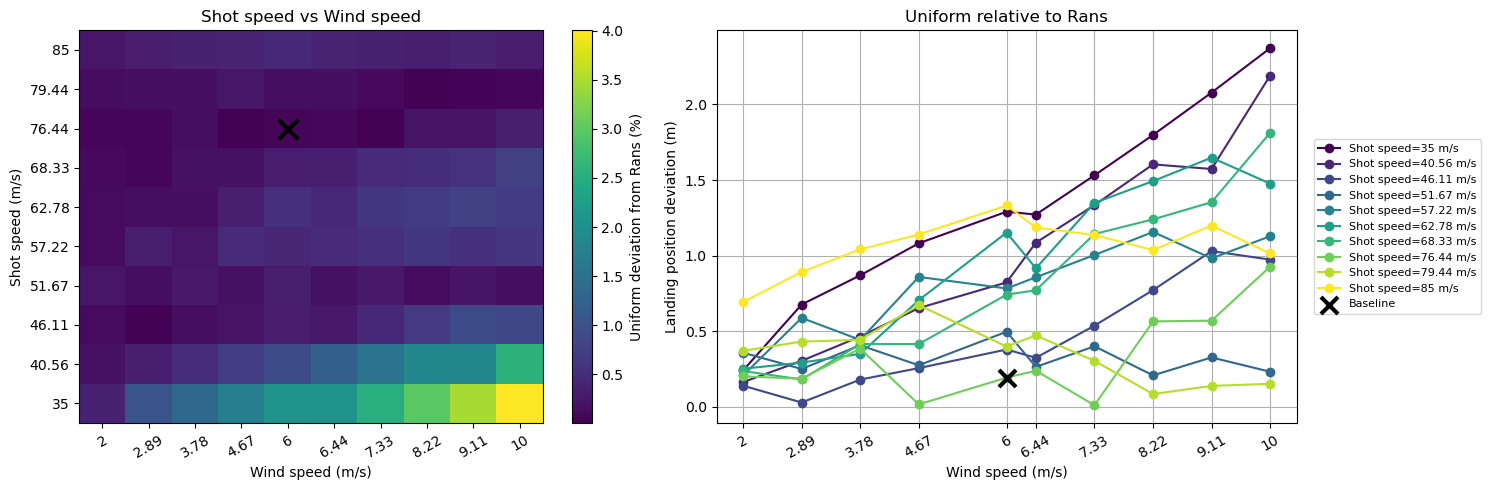

Synthesizing wind field with parameters:  z_height=100, direction=0.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=20.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=40.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=60.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=80.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=100.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=120.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=140.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=160.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=180.0, U_ref=6, z0=0.0

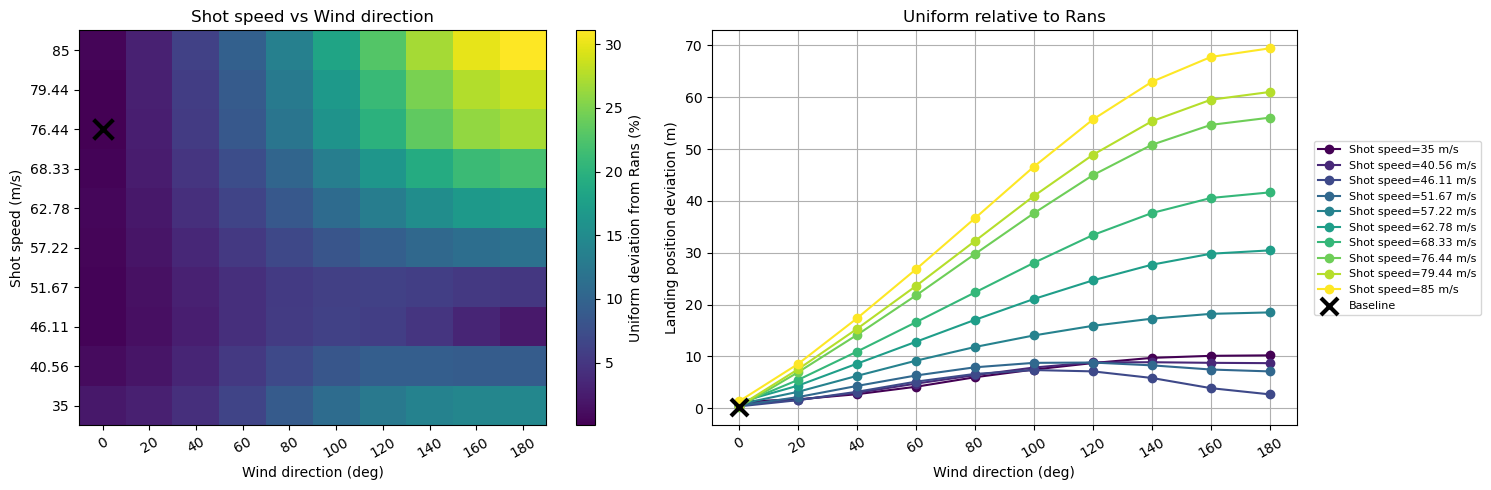

Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind fi

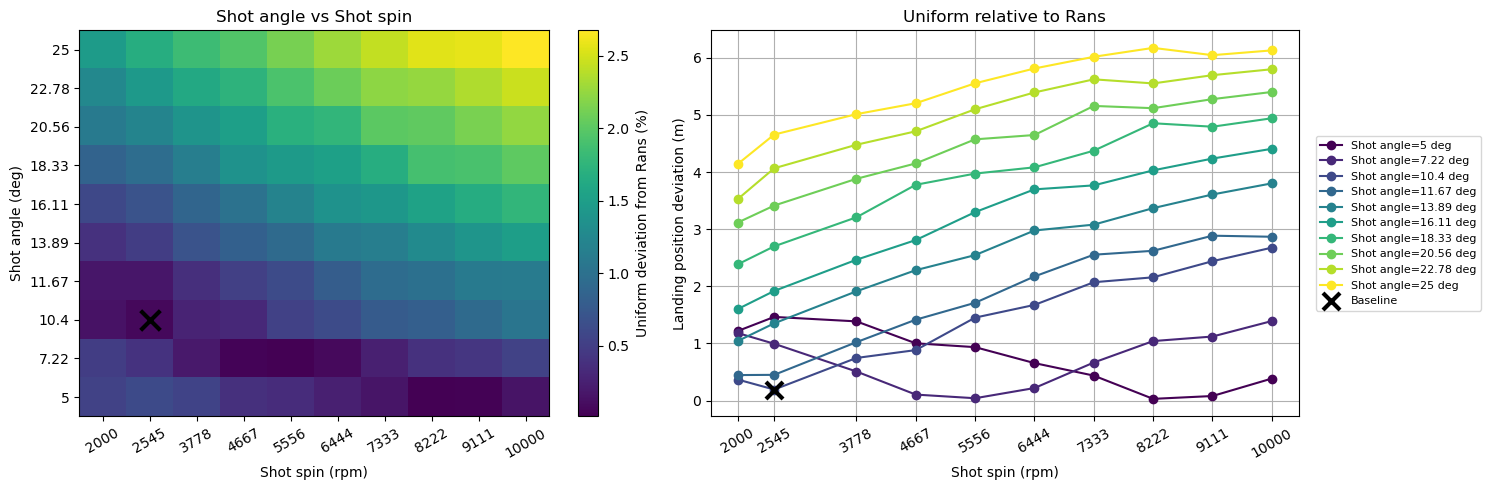

Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=2.0, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=2.888888888888889, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=3.7777777777777777, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=4.666666666666666, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6.0, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6.444444444444445, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=7.333333333333333, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=8.222222222222221, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=9.11111111111111, z0=0.03, z_ref=10.0
Sy

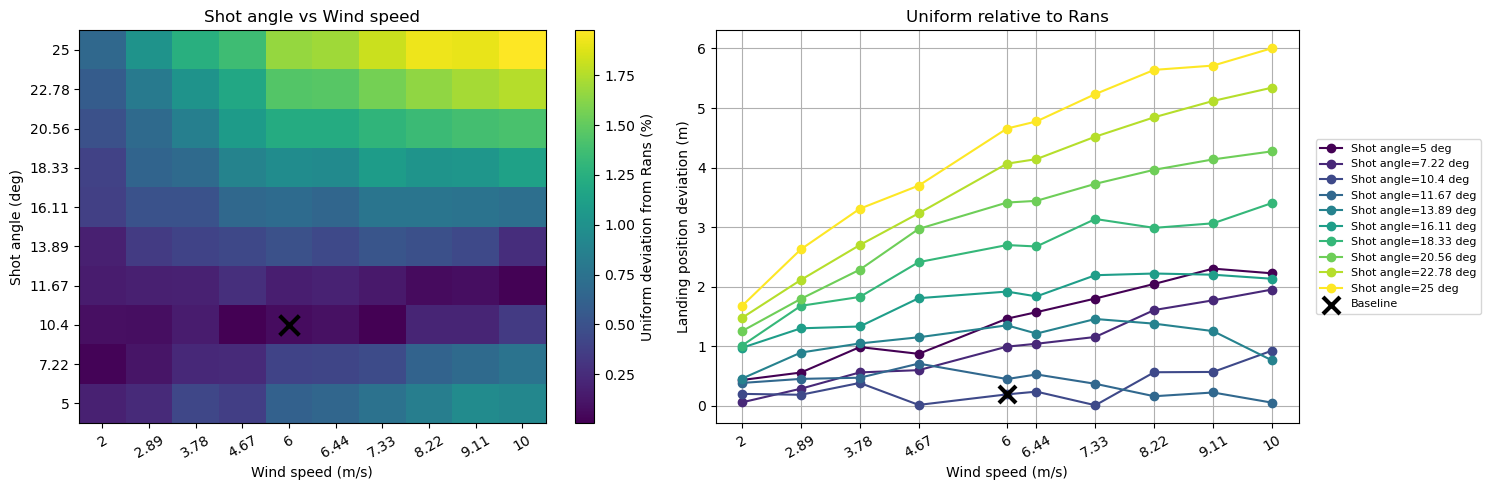

Synthesizing wind field with parameters:  z_height=100, direction=0.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=20.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=40.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=60.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=80.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=100.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=120.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=140.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=160.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=180.0, U_ref=6, z0=0.0

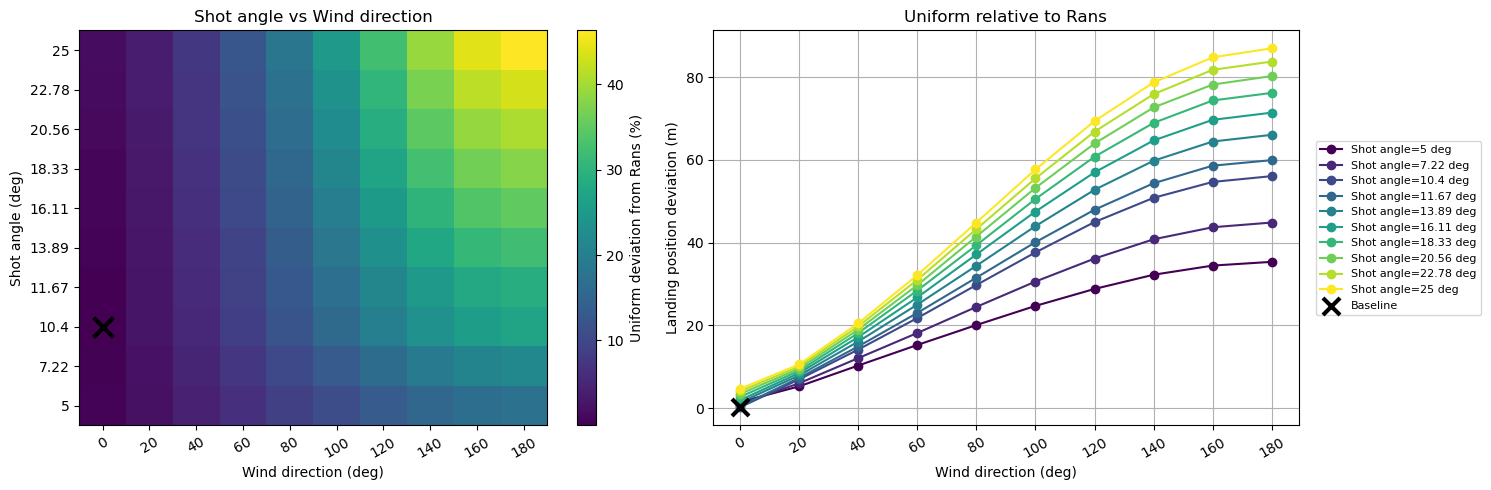

Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=2.0, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=2.888888888888889, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=3.7777777777777777, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=4.666666666666666, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6.0, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=6.444444444444445, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=7.333333333333333, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=8.222222222222221, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=0, U_ref=9.11111111111111, z0=0.03, z_ref=10.0
Sy

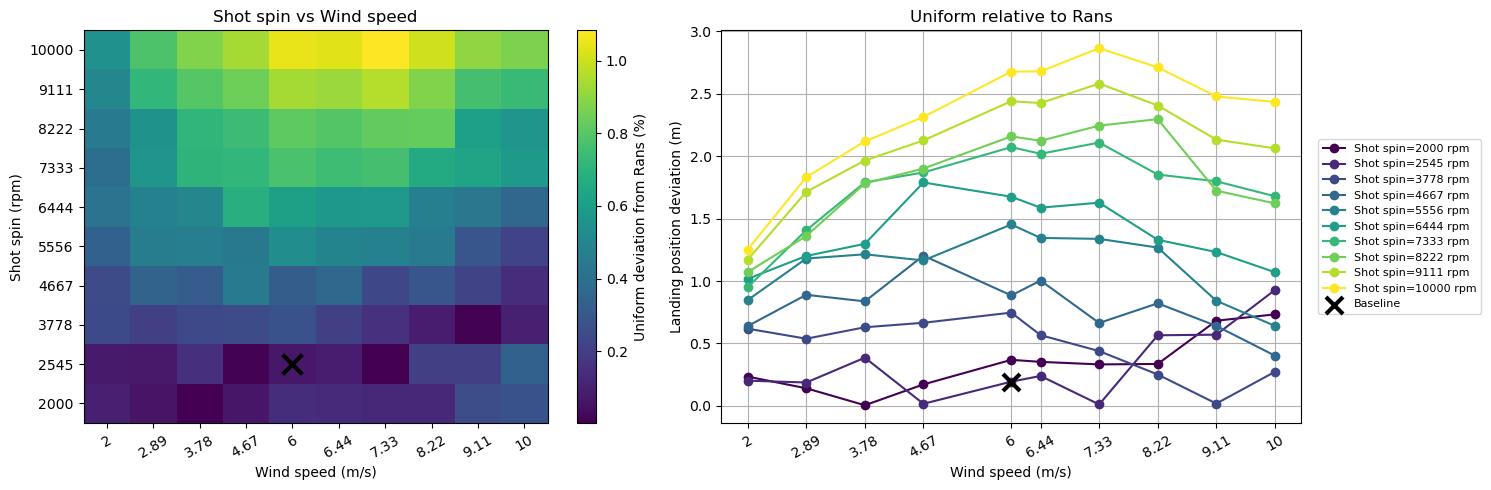

Synthesizing wind field with parameters:  z_height=100, direction=0.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=20.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=40.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=60.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=80.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=100.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=120.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=140.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=160.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=180.0, U_ref=6, z0=0.0

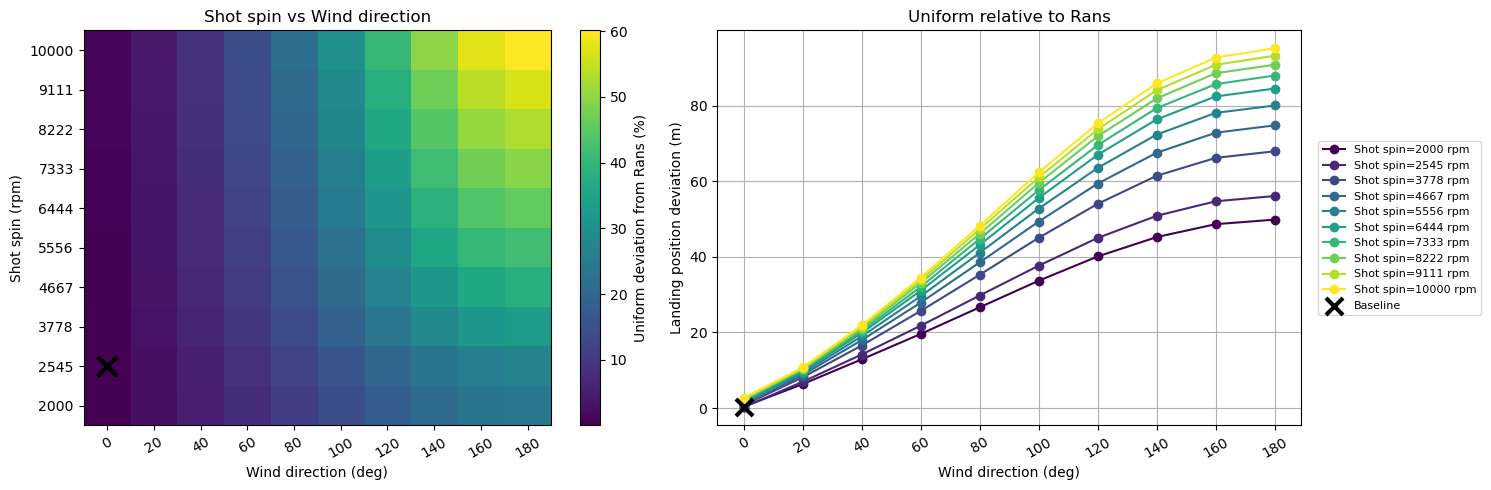

Synthesizing wind field with parameters:  z_height=100, direction=0.0, U_ref=2.0, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=20.0, U_ref=2.0, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=40.0, U_ref=2.0, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=60.0, U_ref=2.0, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=80.0, U_ref=2.0, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=100.0, U_ref=2.0, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=120.0, U_ref=2.0, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=140.0, U_ref=2.0, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=160.0, U_ref=2.0, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=180.

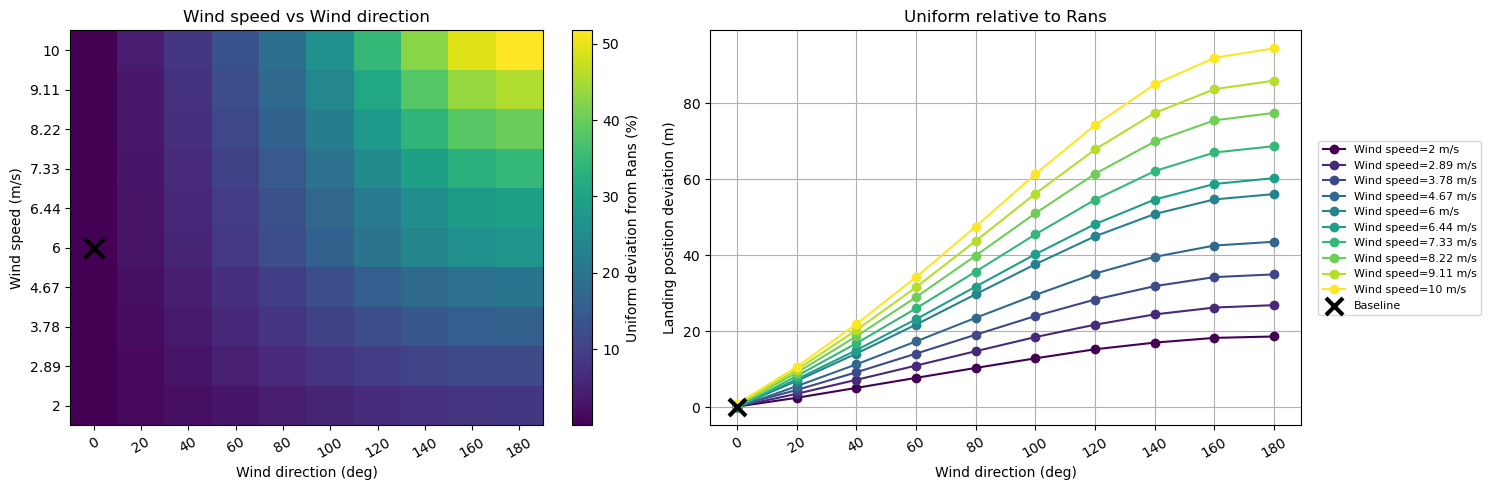

Synthesizing wind field with parameters:  z_height=100, direction=0.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=20.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=40.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=60.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=80.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=100.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=120.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=140.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=160.0, U_ref=6, z0=0.03, z_ref=10.0
Synthesizing wind field with parameters:  z_height=100, direction=180.0, U_ref=6, z0=0.0

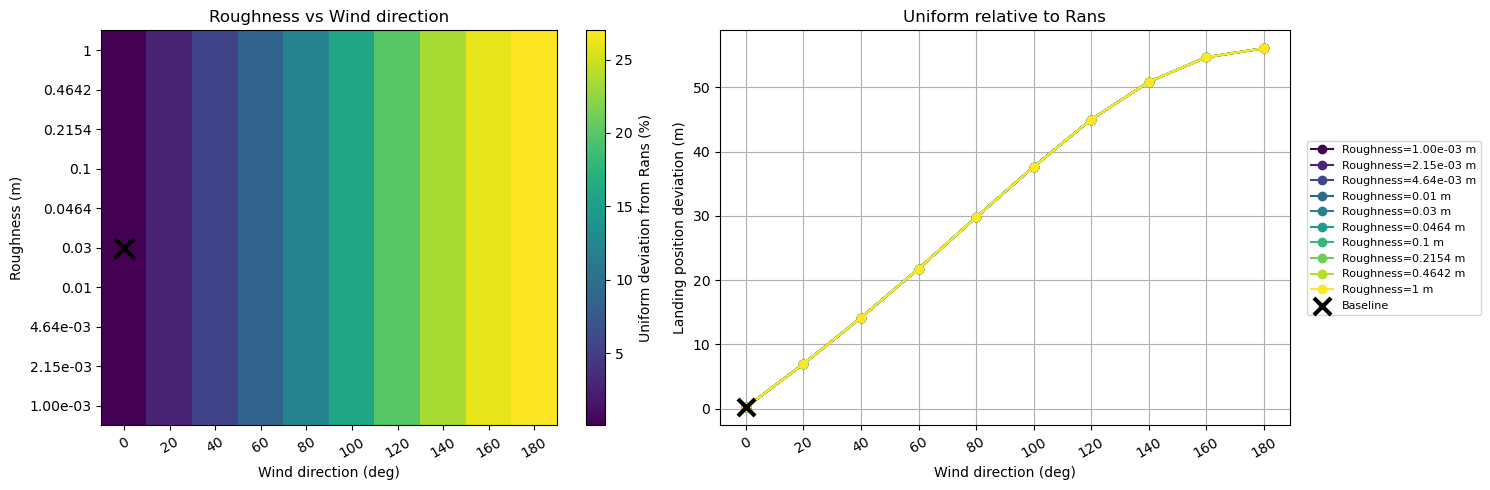

In [ ]:
# Cross parameter variations
varying_two_parameters("shot_speed", "shot_angle", test='uniform', ref='rans')
varying_two_parameters("shot_speed", "shot_spin", test='uniform', ref='rans')
varying_two_parameters("shot_speed", "U_ref", test='uniform', ref='rans')
#varying_two_parameters("shot_speed", "z0", test='uniform', ref='rans')
varying_two_parameters("shot_speed", "direction", test='uniform', ref='rans')
varying_two_parameters("shot_angle", "shot_spin", test='uniform', ref='rans')
varying_two_parameters("shot_angle", "U_ref", test='uniform', ref='rans')
#varying_two_parameters("shot_angle", "z0", test='uniform', ref='rans')
varying_two_parameters("shot_angle", "direction", test='uniform', ref='rans')
varying_two_parameters("shot_spin", "U_ref", test='uniform', ref='rans')
#varying_two_parameters("shot_spin", "z0", test='uniform', ref='rans')
varying_two_parameters("shot_spin", "direction", test='uniform', ref='rans')
#varying_two_parameters("U_ref", "z0", test='uniform', ref='rans')
varying_two_parameters("U_ref", "direction", test='uniform', ref='rans')
varying_two_parameters("z0", "direction", test='uniform', ref='rans')